# Assignment5 - Kaggle competition and Unsupervised learning

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


## Exercise 1 - Kaggle classification competitio

**1.1 Explore data**

Load and inspect dimensions

In [7]:
import pandas as pd
import numpy as np

data = pd.read_pickle("data/a5_q1.pkl")
X_train = data["X_train"]
y_train = data["y_train"]
X_train_ohe = data["X_train_ohe"]


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_train_ohe shape:", X_train_ohe.shape)

X_train shape: (95512, 29)
y_train shape: (95512,)
X_train_ohe shape: (95512, 940)


Identify data types and missingness

In [8]:
# Look for missing values
missing_counts = X_train.isnull().sum()
print(missing_counts[missing_counts > 0])

print(X_train.describe())

children        2
country       395
agent       13081
company     90059
dtype: int64
          lead_time  arrival_date_year  arrival_date_week_number  \
count  95512.000000       95512.000000              95512.000000   
mean     103.849768        2016.157205                 27.152902   
std      106.722804           0.707470                 13.611204   
min        0.000000        2015.000000                  1.000000   
25%       18.000000        2016.000000                 16.000000   
50%       69.000000        2016.000000                 27.000000   
75%      160.000000        2017.000000                 38.000000   
max      709.000000        2017.000000                 53.000000   

       arrival_date_day_of_month  stays_in_weekend_nights  \
count               95512.000000             95512.000000   
mean                   15.823038                 0.928491   
std                     8.786777                 0.999940   
min                     1.000000                 0.000000 

Visual relationships analysis

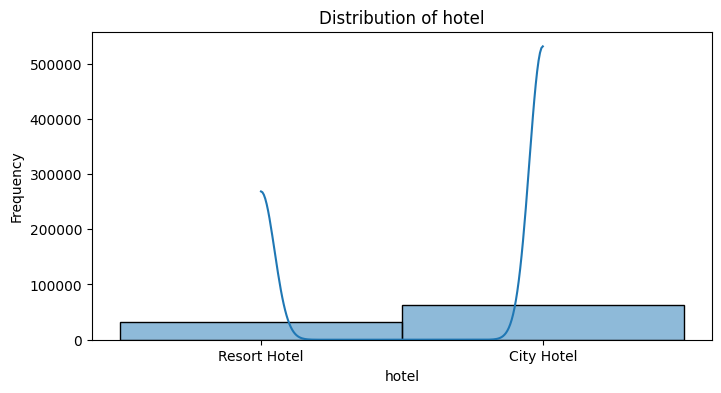

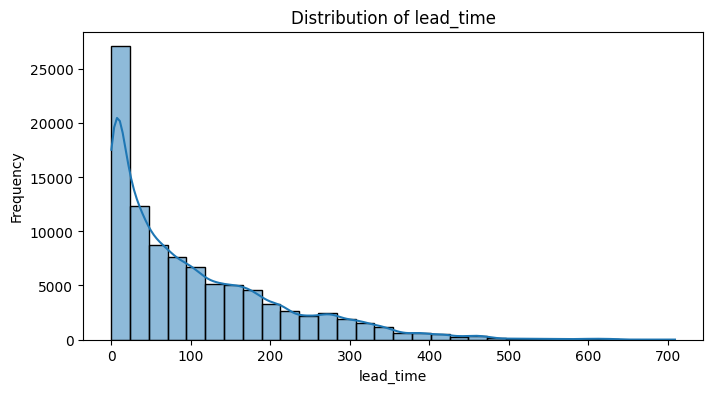

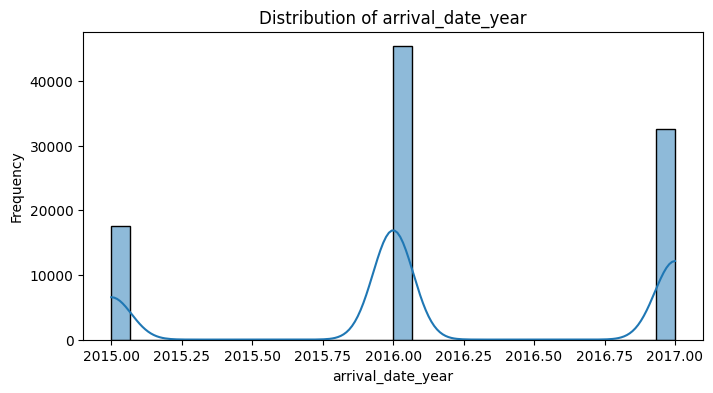

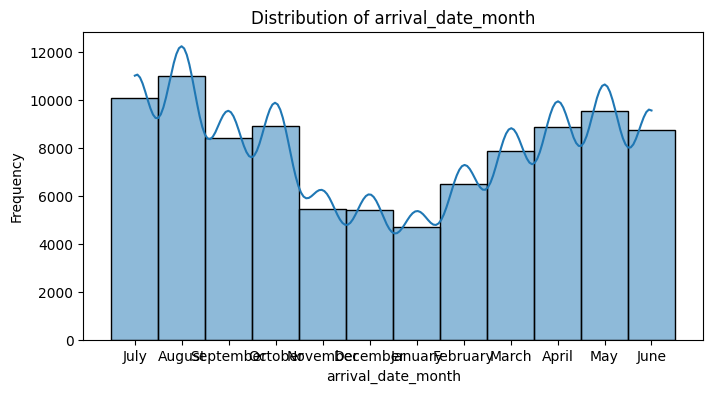

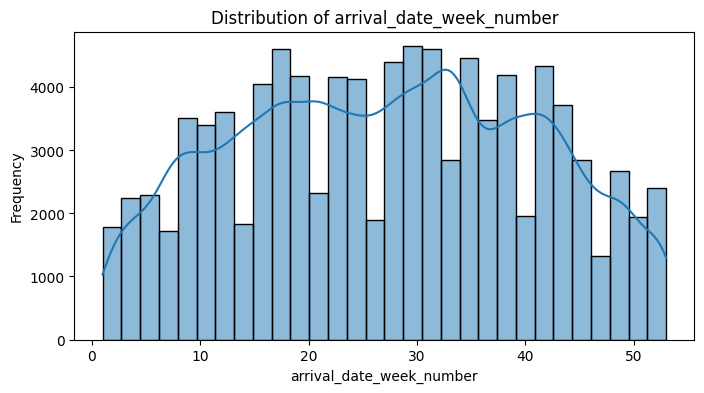

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = X_train.columns[:5]
for col in top_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

**1.2 Preprocess data**

After checking the data in the 1.1, I found some problem in this data.

1. Missing values(Imputation)
    - Company: This feature has an extremely high missing rate, 90059 missing out of 95512. I will either drop this column or convert it into a binary indicator.
    - Agent: Missing values likely represenent direct bookings without an agent. I will impute these with a constant value of 0.
    - Children: There are 2 missing values. Since the median and 75th percentile are both 0, I will fill these with 0.
    - Country: There are 395 missing values. These will be filled with the mode unknown or the most frequet country.

2. Treatment of erroneous data & outliers
    - The adr feature shows a minimum value of -6.38. Since a negative price is impossible, these value will chage to 0.
    - Because features like adr, lead_time, and adults have high variance and different units, I applied StandardScaler. This ensures that distance-based models (like KNN or SVM) are not biased by the scale of the input features.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

X_test_original = data['X_test']
X_test_ohe_raw = pd.get_dummies(X_test_original)

# Reindex X_test_ohe_raw to match the columns of X_train_ohe
X_test_ohe = X_test_ohe_raw.reindex(columns=X_train_ohe.columns, fill_value=0)

# 1. Handle Missing Values (Imputation)
# Based on describe(), children, country, agent, and company have NaNs.
X_train_clean = X_train_ohe.fillna(0)
X_test_clean = X_test_ohe.fillna(0)

# 2. Error Correction
X_train_clean.loc[X_train_clean['adr'] < 0, 'adr'] = 0

#3. Scaling
num_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adults']
scaler = StandardScaler()
X_train_clean[num_cols] = scaler.fit_transform(X_train_clean[num_cols])
X_test_clean[num_cols] = scaler.transform(X_test_clean[num_cols])



**Local validation split**

Split 20% for local validation and 80% for model training

In [11]:
from sklearn.model_selection import train_test_split

y_train_np = np.array(y_train)

# Perform the 80/20 split
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_clean, 
    y_train_np, test_size=0.2, random_state=42, stratify=y_train_np )

print(f"Total training samples available: {X_train_clean.shape[0]}")
print(f"Final Training Set: {X_train_final.shape[0]} samples")
print(f"Validation Set:     {X_val.shape[0]} samples")

Total training samples available: 95512
Final Training Set: 76409 samples
Validation Set:     19103 samples


**1.3 Model training and comparable**

I selected five diverse models to ensure a broad exploration of the hypothesis space:

1. Logistic Regression: Used as a linear baseline. Due to the high dimensionality (940 features), I increased max_iter to 1000 to assist with convergence.      

2. Random Forest: Representing the bagging ensemble method. I utilized 100 estimators and set n_jobs=-1 to leverage parallel processing.        

3. K-Nearest Neighbors (KNN): A non-parametric instance-based learner. I used $k=5$ as a starting point.        

4. XGBoost: A high-performance gradient boosting framework. I monitored its logloss during training to ensure stability.        

5. Neural Network (MLP): A deep learning approach with two hidden layers (64, 32 units) to capture complex, non-linear interactions between features.           

**1.3.1 Training Data**

In [12]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Define the 5 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# Dictionary to store performance and timing data
model_stats = {}

for name, clf in models.items():
    print(f"Training {name}...")
    
    # 1. Track Training Time
    start_train = time.time()
    clf.fit(X_train_final, y_train_final)
    train_time = time.time() - start_train
    
    # 2. Track Prediction Time (on Validation Set)
    start_pred = time.time()
    # We use predict_proba to get confidence scores for ROC/PR curves
    y_probs = clf.predict_proba(X_val)[:, 1]
    pred_time = time.time() - start_pred
    
    # Store all metrics
    model_stats[name] = {
        "probs": y_probs,
        "train_time": train_time,
        "pred_time": pred_time
    }

print("Success: All models trained and validated.")

Training Logistic Regression...


/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...
Training KNN (k=5)...
Training XGBoost...


/usr/local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [20:27:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Neural Network...
Success: All models trained and validated.


**1.3.2 Visualizing Performance**


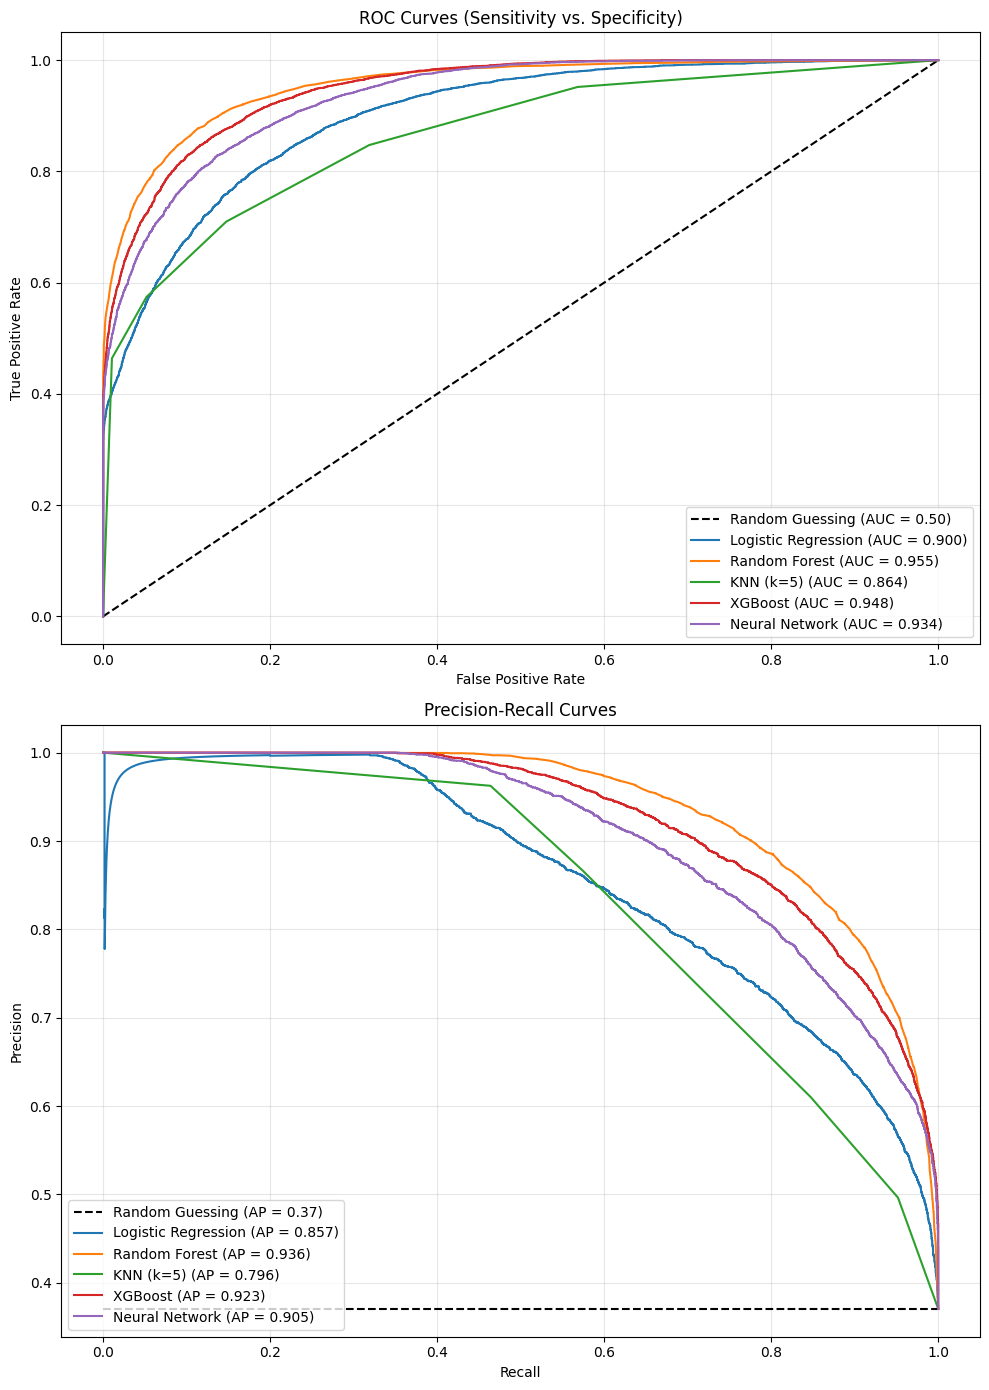

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 14))

# 1. ROC Curve Plotting
ax1.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')

# 2. Precision-Recall Curve Plotting
# Baseline for PR is the proportion of positive samples (cancellations)
baseline_pr = y_val.mean()
ax2.plot([0, 1], [baseline_pr, baseline_pr], 'k--', label=f'Random Guessing (AP = {baseline_pr:.2f})')

for name, stats in model_stats.items():
    y_probs = stats['probs']
    
    # Calculate ROC metrics
    fpr, tpr, _ = roc_curve(y_val, y_probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')
    
    # Calculate PR metrics
    precision, recall, _ = precision_recall_curve(y_val, y_probs)
    ap = average_precision_score(y_val, y_probs)
    ax2.plot(recall, precision, label=f'{name} (AP = {ap:.3f})')

# Formatting the ROC Plot
ax1.set_title('ROC Curves (Sensitivity vs. Specificity)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Formatting the PR Plot
ax2.set_title('Precision-Recall Curves')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The best model is Random Forest, which has AUC = 0.955 and PR = 0.936       
The worst model is KNN(k = 5), which has the less AUC and PR

**1.3.3 Efficiency Comparable**

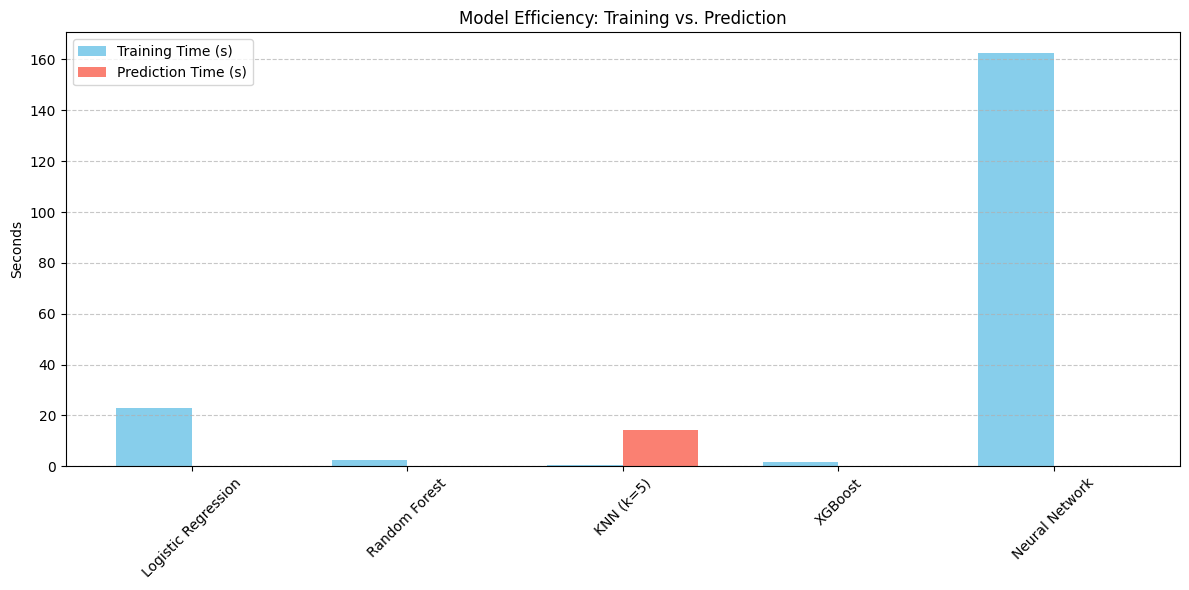

In [18]:
import numpy as np

names = list(model_stats.keys())
train_times = [model_stats[n]['train_time'] for n in names]
pred_times = [model_stats[n]['pred_time'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, train_times, width, label='Training Time (s)', color='skyblue')
ax.bar(x + width/2, pred_times, width, label='Prediction Time (s)', color='salmon')

ax.set_ylabel('Seconds')
ax.set_title('Model Efficiency: Training vs. Prediction')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The efficiency plot highlights a significant contrast between model types.      
While the Neural Network required the most training time (~160s), its prediction was instantaneous.          
Conversely, KNN showed near-zero training time but the highest prediction latency.              
For other models, the prediction time is so small relative to the training time that it is nearly invisible on this scale, making them more suitable for real-time production environments.